##### Setup

In [ ]:
%pip install numpy pandas seaborn matplotlib scikit-learn ipython

##### Change to root for accessing data directory

In [2]:
import os
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks" and Path.exists(current_dir.parent / Path("data")):
    os.chdir(current_dir.parent)
    print(f"Current directory: {Path.cwd()}")
elif current_dir.name == "dt133g-thesis-project":
    print(f"Current directory: {Path.cwd()}")
else:
    print("Ensure data exists before running this notebook..")
    

Current directory: d:\viola\GitHub\dt133g-thesis-project


##### Imports and model names

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import f1_score
from IPython.display import display

pretrained_models = [
    "microsoft/codebert-base",
    "microsoft/graphcodebert-base", 
    "microsoft/unixcoder-base",
    "Salesforce/codet5p-770m",
    "deepseek-ai/deepseek-coder-1.3b-base",
]


##### Load DataFrame and set figure save path

In [41]:
dataset_names = {1: "codet_m4", 2: "droidcollection"}
DATASET_NAME = dataset_names[2]

FULL_MODEL_NAME = ""
MODEL_NAME = ""

FIGURE_OUTDIR = Path("output/figures")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def load_dataset(file_paths=[], dataset_name=DATASET_NAME):
    if dataset_name not in ["droidcollection", "codet_m4"]:
        return pd.DataFrame()
    
    file_paths = file_paths

    if not file_paths:
        for name in pretrained_models:

            FULL_MODEL_NAME = name
            MODEL_NAME = FULL_MODEL_NAME.split("/")[-1].rsplit("-")[0]

            file_paths.append(Path(f"data/fine_tune/models/{DATASET_NAME}/{FULL_MODEL_NAME}/eval_outputs/ood_metrics_{MODEL_NAME}.csv"))

    def get_df_with_lang_col(file_paths):
        raw_dfs = []
        for file in file_paths:
            file_df = pd.read_csv(file)
            file_df = file_df[file_df["true_label"] != "true_label"]
            test_df = pd.read_parquet(f"data/_06_generated_splits/{dataset_name}/test.parquet")
            tier_df = pd.read_parquet(f"data/transformations/{dataset_name}/tier_1/augmented_dataset.parquet")

            snippet_langs = tier_df.loc[tier_df["original_code"] == test_df["code"], ["snippet_id", "language"]]
            file_df = file_df.merge(snippet_langs, on="snippet_id", how="left")

            raw_dfs.append(file_df)

        return pd.concat(raw_dfs)


    df_raw = get_df_with_lang_col(file_paths)
    return df_raw


df_raw = load_dataset(dataset_name=DATASET_NAME)

LANGUAGES = df_raw["language"].unique()
ALL_MODELS = df_raw["model_name"].unique()
TIER_ORDER = df_raw["tier"].unique()

print("Programming Languages:")
print(LANGUAGES)
print("-"*66)
print("DataFrame Columns:")
print(df_raw.columns.values)
print("-"*66)
print("Model Names:")
print(ALL_MODELS)
print("-"*66)
print("Tiers:")
print(TIER_ORDER)


Programming Languages:
['cpp' 'java' 'python']
------------------------------------------------------------------
DataFrame Columns:
['model_name' 'model_type' 'tier' 'snippet_id' 'true_label' 'pred_label'
 'is_correct' 'conf_target' 'entropy' 'mutual_info' 'language']
------------------------------------------------------------------
Model Names:
['codebert' 'graphcodebert' 'unixcoder' 'codet5p' 'deepseek']
------------------------------------------------------------------
Tiers:
['test' 'tier_1' 'tier_2' 'tier_3' 'tier_4']


##### Helpers

In [42]:
def save_figure(fig, name, dpi=300):
    pdf_path = FIGURE_OUTDIR / f"{name}.pdf"
    fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {pdf_path}")


def build_metrics_summary(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    df_clean = df_source.copy()
    df_clean = df_clean.dropna(subset=["true_label", "pred_label"])

    df_clean["true_label"] = df_clean["true_label"].astype(float).astype(int)
    df_clean["pred_label"] = df_clean["pred_label"].astype(float).astype(int)
    df_clean["entropy"] = pd.to_numeric(df_clean["entropy"], errors="coerce")
    df_clean["mutual_info"] = pd.to_numeric(df_clean["mutual_info"], errors="coerce")

    languages = df_clean["language"].unique()

    metrics_rows = []

    for model in models:
        for tier in tiers:
            for lang in languages:
                    slice_df = df_clean[
                        (df_clean["model_name"] == model) & (df_clean["tier"] == tier) & (df_clean["language"] == lang)
                    ]

                    if slice_df.empty:
                        continue

                    y_true = slice_df["true_label"].to_numpy()
                    y_pred = slice_df["pred_label"].to_numpy()
                    entropy = slice_df["entropy"].dropna().to_numpy()
                    mutual_info = slice_df["mutual_info"].dropna().to_numpy()

                    row = {
                        "model_name": model,
                        "tier": tier,
                        "language": lang,
                        "accuracy": float(np.mean(y_true == y_pred)),
                        "macro_f1": float(
                            f1_score(y_true, y_pred, average="macro", zero_division=0)
                        ),
                        "entropy": float(np.mean(entropy)),
                        "entropy_std": float(np.std(entropy, ddof=0)),
                        "mutual_info": float(np.mean(mutual_info)),
                        "mutual_info_std": float(np.std(mutual_info, ddof=0)),
                    }

                    metrics_rows.append(row)

    return pd.DataFrame(metrics_rows)


def build_delta_summary(df_source, baseline="test"):
    summary_df = df_source.copy()

    baseline = (
        summary_df[summary_df["tier"] == baseline]
        .rename(columns={
            "accuracy": "baseline_accuracy",
            "macro_f1": "baseline_macro_f1",
            "entropy": "baseline_entropy",
            "mutual_info": "baseline_mutual_info",
            "entropy_std": "baseline_entropy_std",
            "mutual_info_std": "baseline_mutual_info_std",
        })[["model_name", "language", "baseline_accuracy", "baseline_macro_f1", "baseline_entropy", "baseline_mutual_info", "baseline_entropy_std", "baseline_mutual_info_std"]]
    )
    summary_df = summary_df.merge(baseline, on=["model_name", "language"], how="left")

    summary_df["accuracy_delta"] = summary_df["accuracy"] - summary_df["baseline_accuracy"]
    summary_df["macro_f1_delta"] = summary_df["macro_f1"] - summary_df["baseline_macro_f1"]
    summary_df["entropy_delta"] = summary_df["entropy"] - summary_df["baseline_entropy"]
    summary_df["mutual_info_delta"] = summary_df["mutual_info"] - summary_df["baseline_mutual_info"]

    return summary_df


##### Plot configuration

In [43]:
METRICS_LIST = ["accuracy", "macro_f1", "entropy", "mutual_info"]

sns.set_style("whitegrid")
palette = sns.color_palette("deep", n_colors=len(ALL_MODELS))
MODEL_COLORS = {model: color for model, color in zip(ALL_MODELS, palette)}
HEATMAP_NEG = sns.color_palette("viridis", as_cmap=True)
HEATMAP_POS = sns.color_palette("viridis_r", as_cmap=True)

MODEL_LABELS = {
    "codebert": "CodeBERT",
    "graphcodebert": "GraphCodeBERT",
    "unixcoder": "UniXcoder",
    "codet5p": "CodeT5+",
    "deepseek": "DeepSeek Coder",
}

TIER_LABELS = {
    "test": "base (T0)",
    "tier_1": "surface (T1)",
    "tier_2": "natural (T2)",
    "tier_3": "adversarial (T3)",
    "tier_4": "destructive (T4)"
}

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "entropy": "Predictive Entropy",
    "mutual_info": "Mutual Information",
}

METRIC_DELTA_LABELS = {
    "accuracy": "Δ Accuracy",
    "macro_f1": "Δ Macro-F1",
    "entropy": "Δ Predictive Entropy",
    "mutual_info": "Δ Mutual Information",
}


## General Analysis

#### General

In [44]:
def build_comparison_tables(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    table_a_rows = []
    table_b_rows = []

    df_summary = build_metrics_summary(df_source)
    df_deltas = build_delta_summary(df_summary)

    for model in models:
        model_summary = df_summary[df_summary["model_name"] == model]
        model_deltas = df_deltas[df_deltas["model_name"] == model]

        summary_by_tier = model_summary.groupby("tier").mean(numeric_only=True).reindex(tiers)
        deltas_by_tier = model_deltas.groupby("tier").mean(numeric_only=True).reindex(tiers)

        if "test" not in summary_by_tier.index:
            continue

        table_a_rows.append(
            {
                "Model": MODEL_LABELS[model],
                "Baseline Accuracy": float(summary_by_tier.loc["test", "accuracy"]),
                "Baseline Macro-F1": float(summary_by_tier.loc["test", "macro_f1"]),
                "Mean Entropy": float(summary_by_tier.loc["test", "entropy"]),
                "Std Entropy": float(summary_by_tier.loc["test", "entropy_std"]),
                "Mean Mutual Info": float(summary_by_tier.loc["test", "mutual_info"]),
                "Std Mutual Info": float(summary_by_tier.loc["test", "mutual_info_std"]),
            }
        )

        if "tier_4" not in deltas_by_tier.index:
            continue

        active_tiers_delta = deltas_by_tier.loc[deltas_by_tier.index.isin(tiers)]

        table_b_rows.append(
            {
                "Model": MODEL_LABELS[model],
                "Total Acc. Loss (T4)": float(deltas_by_tier.loc["tier_4", "accuracy_delta"]),
                "Total F1 Loss (T4)": float(deltas_by_tier.loc["tier_4", "macro_f1_delta"]),
                "Mean Entropy": float(active_tiers_delta["entropy_delta"].mean()),
                "Mean Mutual Info": float(active_tiers_delta["mutual_info_delta"].mean()),
            }
        )

    table_a = pd.DataFrame(table_a_rows)
    table_b = pd.DataFrame(table_b_rows)

    return table_a, table_b

comparison_table_a, comparison_table_b = build_comparison_tables(df_raw)

ds_title = f"[{DATASET_NAME.upper().replace('_', '-')}]"
print(f"Table A: Absolute Baseline Performance ({ds_title})")
display(comparison_table_a.style.hide(axis="index").format({
    "Baseline Accuracy": "{:.3f}",
    "Baseline Macro-F1": "{:.3f}",
    "Mean Entropy": "{:.3f}",
    "Std Entropy": "(±{:.3f})",
    "Mean Mutual Info": "{:.3f}",
    "Std Mutual Info": "(±{:.3f})",
}))

print(f"\nTable B: Tier-by-Tier Decay Summary ({ds_title})")
display(comparison_table_b.style.hide(axis="index").format({
    "Total Acc. Loss (T4)": "{:+.3f}",
    "Total F1 Loss (T4)": "{:+.3f}",
    "Mean Entropy": "{:+.3f}",
    "Mean Mutual Info": "{:+.3f}",
}))


Table A: Absolute Baseline Performance ([DROIDCOLLECTION])


Model,Baseline Accuracy,Baseline Macro-F1,Mean Entropy,Std Entropy,Mean Mutual Info,Std Mutual Info
CodeBERT,0.985,0.985,0.018,(±0.071),0.004,(±0.032)
GraphCodeBERT,0.985,0.985,0.021,(±0.078),0.004,(±0.027)
UniXcoder,0.972,0.972,0.029,(±0.107),0.007,(±0.040)
CodeT5+,0.975,0.975,0.040,(±0.125),0.006,(±0.022)
DeepSeek Coder,0.892,0.892,0.186,(±0.233),0.027,(±0.046)



Table B: Tier-by-Tier Decay Summary ([DROIDCOLLECTION])


Model,Total Acc. Loss (T4),Total F1 Loss (T4),Mean Entropy,Mean Mutual Info
CodeBERT,-0.098,-0.100,+0.016,+0.006
GraphCodeBERT,-0.096,-0.098,+0.013,+0.004
UniXcoder,-0.083,-0.086,+0.008,+0.004
CodeT5+,-0.105,-0.110,+0.022,+0.002
DeepSeek Coder,-0.063,-0.064,+0.056,+0.009


##### Generate Line Plots

Saved: output\figures\droidcollection_line_accuracy.pdf


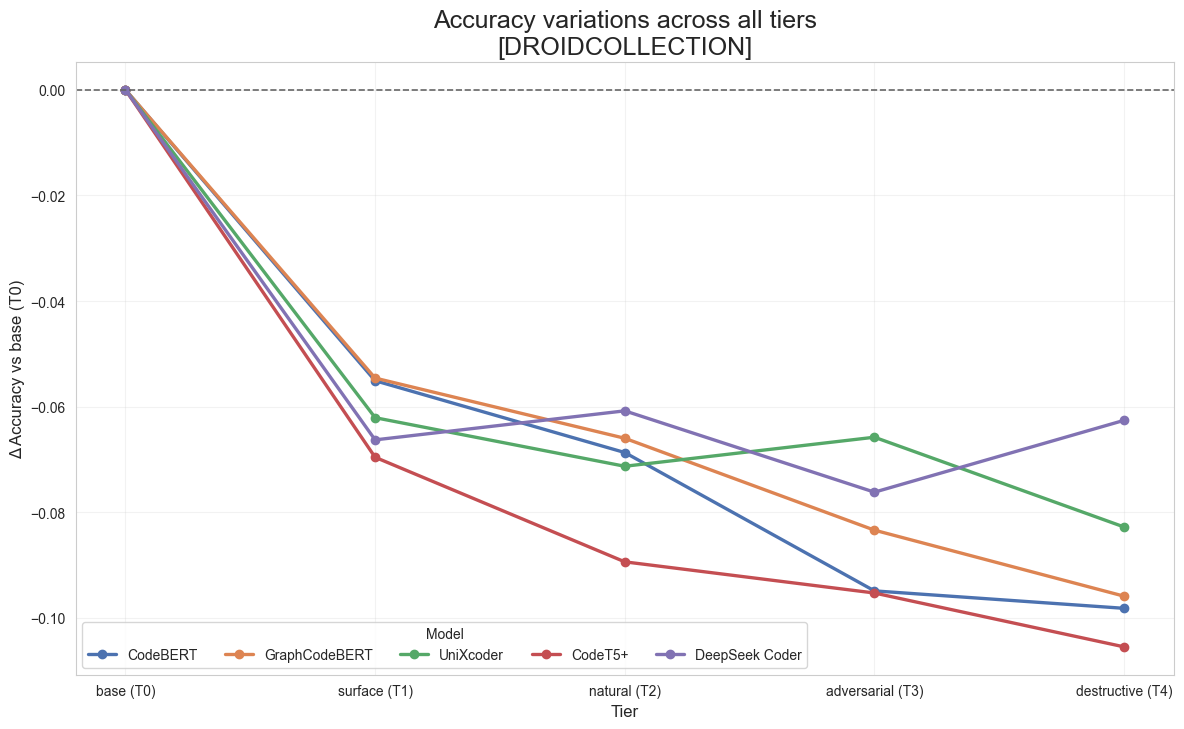

Saved: output\figures\droidcollection_line_macro_f1.pdf


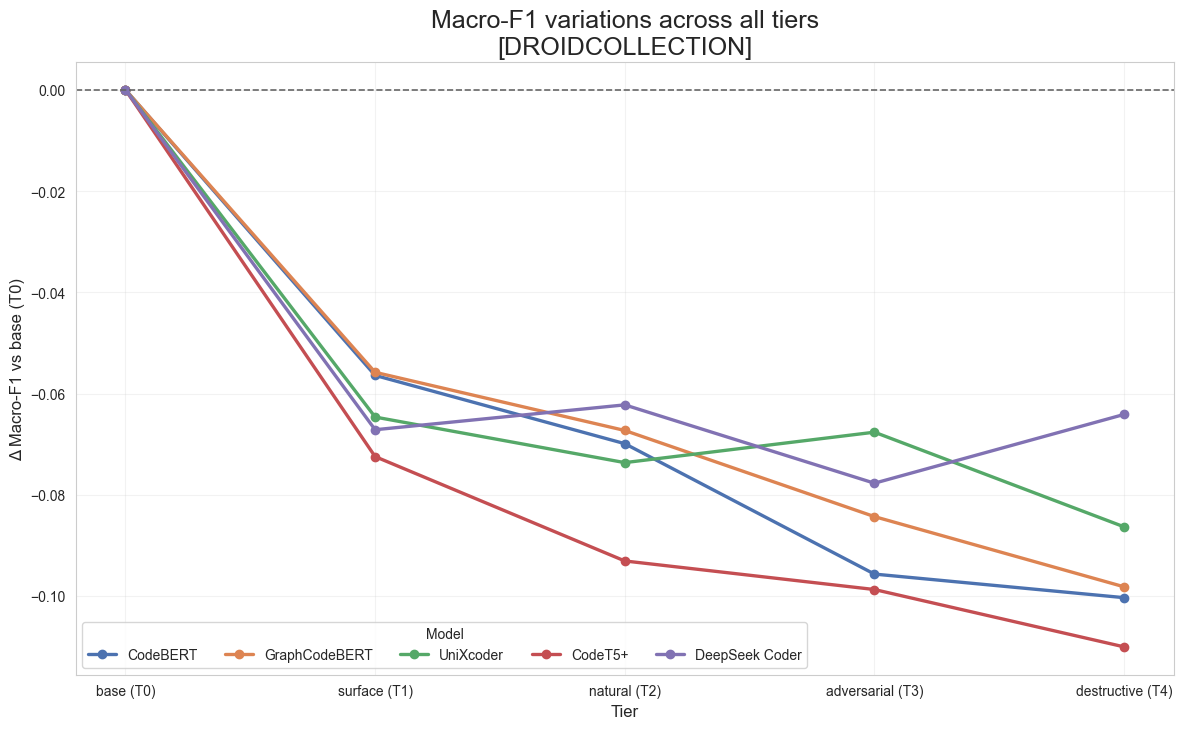

,model_name,tier,language,accuracy,macro_f1,entropy,entropy_std,mutual_info,mutual_info_std
0,codebert,test,cpp,0.988899,0.988899,0.014912,0.059240,0.002532,0.024408
1,codebert,test,java,0.985599,0.985598,0.017803,0.071762,0.004483,0.032513
2,codebert,test,python,0.979304,0.979304,0.022753,0.081635,0.005653,0.038292
3,codebert,tier_1,cpp,0.980498,0.980497,0.022269,0.085857,0.005321,0.036195
4,codebert,tier_1,java,0.980198,0.980197,0.023445,0.088526,0.007002,0.044411


In [45]:
def plot_line(delta_df, metrics=METRICS_LIST, tiers=TIER_ORDER, models=ALL_MODELS):
    pretty_tiers = [TIER_LABELS[t] for t in tiers]

    for metric in metrics:
        fig, ax = plt.subplots(figsize=(12, 7.4))

        for model in models:
            model_df = (
                delta_df[delta_df["model_name"] == model]
                .groupby("tier")
                .mean(numeric_only=True)
                .reindex(tiers)
            )

            deltas = model_df[f"{metric}_delta"]
            if deltas.dropna().empty:
                continue

            ax.plot(
                np.arange(len(tiers)),
                deltas.values,
                marker="o",
                linewidth=2.4,
                color=MODEL_COLORS.get(model, "#333333"),
                label=MODEL_LABELS[model],
            )

        ax.axhline(0.0, color="#666666", linestyle="--", linewidth=1.2)
        ds_name = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        metric_name = f"{METRIC_LABELS[metric]}"
        plot_title = f"{metric_name} variations across all tiers"
        plot_title += f"\n{ds_name}"
        ax.set_title(
            plot_title,
            fontsize=18,
        )
        ax.set_xlabel("Tier", fontsize=12)
        ax.set_ylabel(f"{METRIC_DELTA_LABELS[metric]} vs {TIER_LABELS['test']}", fontsize=12)
        ax.set_xticks(np.arange(len(tiers)))
        ax.set_xticklabels(pretty_tiers)
        ax.grid(alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles,
                labels,
                title="Model",
                ncol=min(len(labels), 5),
                frameon=True,
                fontsize=10,
            )

        fig.tight_layout()

        save_path = f"{DATASET_NAME}_line_{metric}"
        # if language:
        #     save_path += f"_{language}"
        save_figure(fig, save_path)

        plt.show()


summary_df = build_metrics_summary(df_raw)
delta_df = build_delta_summary(summary_df)

plot_line(delta_df, metrics=["accuracy", "macro_f1"])

summary_df.head()


##### Generate KDE plots (MI vs Entropy)

In [46]:
def plot_model_mi_entropy_kde(df_source, models=ALL_MODELS, tiers=TIER_ORDER, language=None):
    df_clean = df_source.copy()

    df_clean["entropy"] = pd.to_numeric(df_clean["entropy"], errors="coerce")
    df_clean["mutual_info"] = pd.to_numeric(df_clean["mutual_info"], errors="coerce")
    
    df_clean = df_clean.dropna(subset=["entropy", "mutual_info", "tier", "model_name"])

    for model in models:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.grid(True, linestyle=":", alpha=0.4)
        
        df_model = df_clean[df_clean["model_name"] == model]
        
        if df_model.empty:
            ax.set_title(f"No data for model: {model}")
            continue

        sns.kdeplot(
            data=df_model,
            x="entropy",
            y="mutual_info",
            hue="tier",
            hue_order=tiers,
            ax=ax,
            fill=False,
            levels=5,
            linewidths=1.5,
            alpha=0.8,
            warn_singular=False
        )

        ax.set_ylim(ymax=0.62)
        ax.set_xlim(xmax=0.85)
        ds_title = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        plot_title = f"Mutual Information vs. Entropy for {MODEL_LABELS[model]}"
        if language:
            plot_title += f" ({language.title().replace('pp', '++')})\n{ds_title}"
        else:
            plot_title += f"\n{ds_title}"
        ax.set_title(plot_title, fontsize=16, pad=10)
        ax.set_xlabel("Predictive Entropy", fontsize=12)
        ax.set_ylabel("Mutual Information", fontsize=12)

        handles = [
            Line2D([0], [0], color=sns.color_palette("deep", len(tiers))[i], lw=2)
            for i, t in enumerate(tiers)
        ]
        labels = [TIER_LABELS[t] for t in tiers]

        ax.legend(
            handles,
            labels,
            title="Mutation Tiers",
            frameon=True,
            fontsize=10,
            title_fontsize=11,
            loc="upper left",
        )

        save_path = f"{DATASET_NAME}_mi_entropy_kde_{model}"
        if language:
            save_path += f"_{language}"
        save_figure(fig, save_path)

        plt.tight_layout(pad=3.0)
        
        plt.show()


In [ ]:
plot_model_mi_entropy_kde(df_raw)

### Ablation Study


##### Helpers

In [48]:
TIER_NAME = "tier_1"
ABLATION_FILE_PREFIX = f"{TIER_NAME}_no_"


def format_tier_label(tier_name):
    return tier_name.replace(ABLATION_FILE_PREFIX, "T1 - no ").replace("_", " ")


def load_ablation_df(dataset_name=DATASET_NAME):
    base_dir = Path(f"data/fine_tune/models/{DATASET_NAME}/")
    file_paths = []

    for csv_path in sorted(base_dir.rglob("tier_*_ablation_metrics_*.csv")):
        file_paths.append(csv_path)

    df_raw_abl = load_dataset(file_paths, dataset_name=dataset_name)
    return df_raw_abl


In [49]:
df_raw_abl = load_ablation_df()

df_raw_abl = pd.concat([df_raw.loc[df_raw["tier"] == TIER_NAME], df_raw_abl])
df_raw_abl["dataset"] = DATASET_NAME

abl_tiers = df_raw_abl['tier'].unique()
abl_summary_df = build_metrics_summary(df_raw_abl, tiers=abl_tiers)
abl_delta_df = build_delta_summary(abl_summary_df, baseline=TIER_NAME)

ABLATION_TIERS = [t for t in abl_tiers if t != TIER_NAME]


##### Generate Bar Plot

In [50]:
def plot_ablation_barplot(summary_df, tiers=ABLATION_TIERS, baseline=TIER_NAME, models=ALL_MODELS, metrics=["macro_f1"], language=None):
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(12, 7.4))
        x = np.arange(len(tiers))

        plot_data = []
        for model in models:
            model_df = summary_df[summary_df["model_name"] == model]
            model_df = model_df.groupby("tier").mean(numeric_only=True).reindex(tiers)
            delta_col = f"{metric}_delta" if f"{metric}_delta" in model_df.columns else metric

            for tier in tiers:
                val = model_df.loc[tier, delta_col]
                plot_data.append(
                    {
                        "tier": tier,
                        "model_pretty": MODEL_LABELS[model],
                        "delta": val if pd.notna(val) else 0.0,
                    }
                )

        plot_df = pd.DataFrame(plot_data)
        hue_order = [MODEL_LABELS[m] for m in models]
        palette = {MODEL_LABELS[m]: MODEL_COLORS.get(m, "#333333") for m in models}

        sns.barplot(
            data=plot_df,
            x="tier",
            y="delta",
            hue="model_pretty",
            hue_order=hue_order,
            order=tiers,
            palette=palette,
            ax=ax,
            edgecolor="#333333",
            linewidth=0.8,
            alpha=0.9,
        )

        ax.axhline(0.0, color="#666666", linestyle="--", linewidth=1.2)
        ax.set_ylim(-0.01, 0.12)
        ds_name = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        plot_title = f"{METRIC_LABELS[metric]} variations across three tier 1 variants"
        if language:
            plot_title += f" for {language.title().replace('pp', '++')}\n{ds_name}"
        else:
            plot_title += f"\n{ds_name}"
        ax.set_title(
            plot_title,
            fontsize=18,
            fontweight="medium",
        )
        ax.set_xlabel("Tier", fontsize=12)
        ax.set_ylabel(f"{METRIC_DELTA_LABELS[metric]} vs {TIER_LABELS[baseline]}", fontsize=12)

        ax.set_xticks(x)
        ax.set_xticklabels([format_tier_label(t) for t in tiers])
        ax.grid(alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles,
                labels,
                title="Model",
                title_fontsize=12,
                ncol=1,
                frameon=True,
                fontsize=10,
                loc="upper left"
            )

        fig.tight_layout()
        tier_name = "_".join(tiers[0].split("_")[:2])

        save_path = f"{DATASET_NAME}_ablation_{metric}_{tier_name}"
        if language:
            save_path += f"_{language}"
        save_figure(fig, save_path)
        plt.show()


Saved: output\figures\droidcollection_ablation_macro_f1_tier_1.pdf


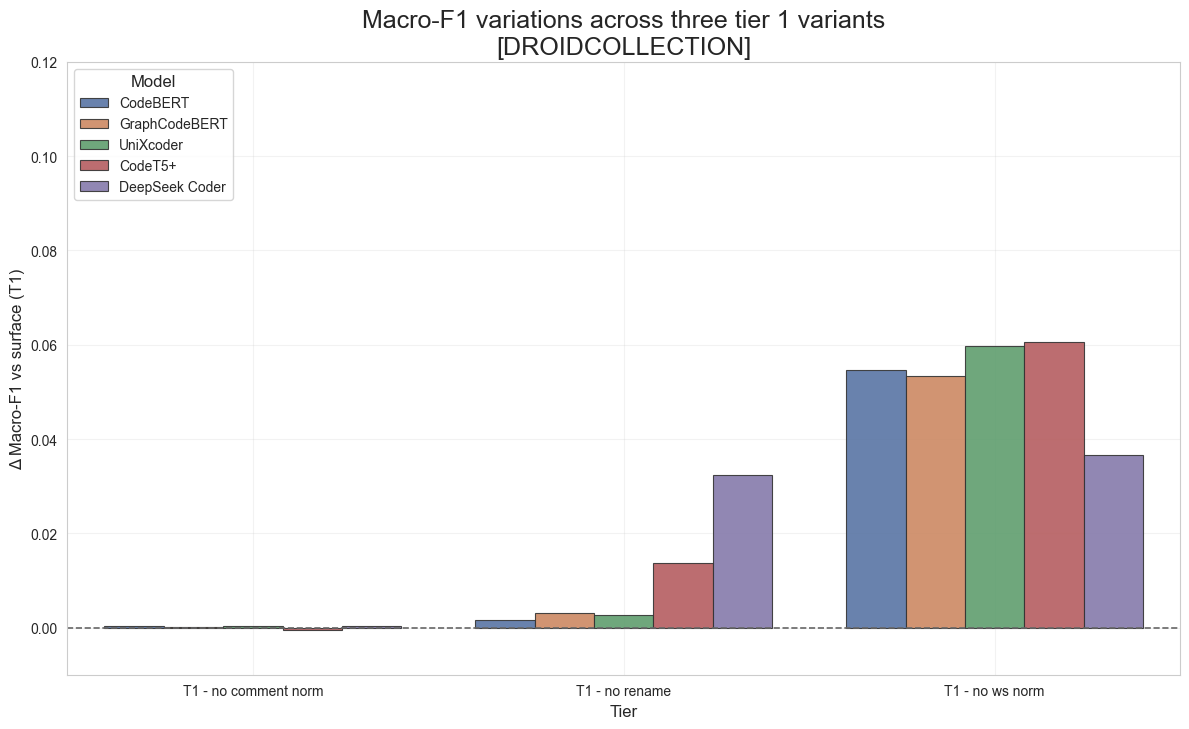

In [51]:
plot_ablation_barplot(abl_delta_df)

##### Bar plot by language

In [52]:
def plot_ablation_barplot_by_language(summary_df, tiers=ABLATION_TIERS, baseline=TIER_NAME, metrics=["macro_f1"]):
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(12, 7.4))
        x = np.arange(len(tiers))

        filtered_df = summary_df[summary_df["tier"].isin(tiers)].copy()
        delta_col = f"{metric}_delta" if f"{metric}_delta" in filtered_df.columns else metric

        aggregated_df = (
            filtered_df.groupby(["tier", "language"], as_index=False)[delta_col]
            .mean()
        )

        unique_languages = sorted(aggregated_df["language"].unique())

        sns.barplot(
            data=aggregated_df,
            x="tier",
            y=delta_col,
            hue="language",
            hue_order=unique_languages,
            order=tiers,
            palette="viridis",
            edgecolor="#333333",
            linewidth=0.8,
            alpha=0.9,
            ax=ax,
        )

        ax.axhline(0.0, color="#666666", linestyle="--", linewidth=1.2)
        ax.set_ylim(ymax=0.15)
        
        ds_name = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        plot_title = f"{METRIC_LABELS[metric]} variations across three tier 1 variants by language\n{ds_name}"
        
        ax.set_title(plot_title, fontsize=16, fontweight="medium")
        ax.set_xlabel("Tier", fontsize=12)
        ax.set_ylabel(f"{METRIC_DELTA_LABELS[metric]} vs {TIER_LABELS[baseline]}", fontsize=12)

        ax.set_xticks(x)
        ax.set_xticklabels([format_tier_label(t) for t in tiers])
        ax.grid(alpha=0.25, axis='y')

        ax.legend(
            title="Language",
            title_fontsize=12,
            frameon=True,
            fontsize=10,
            loc="upper left"
        )

        fig.tight_layout()
        tier_name = "_".join(tiers[0].split("_")[:2])

        save_path = f"{DATASET_NAME}_ablation_by_lang_{metric}_{tier_name}"
        save_figure(fig, save_path)
        plt.show()

Saved: output\figures\droidcollection_ablation_by_lang_macro_f1_tier_1.pdf


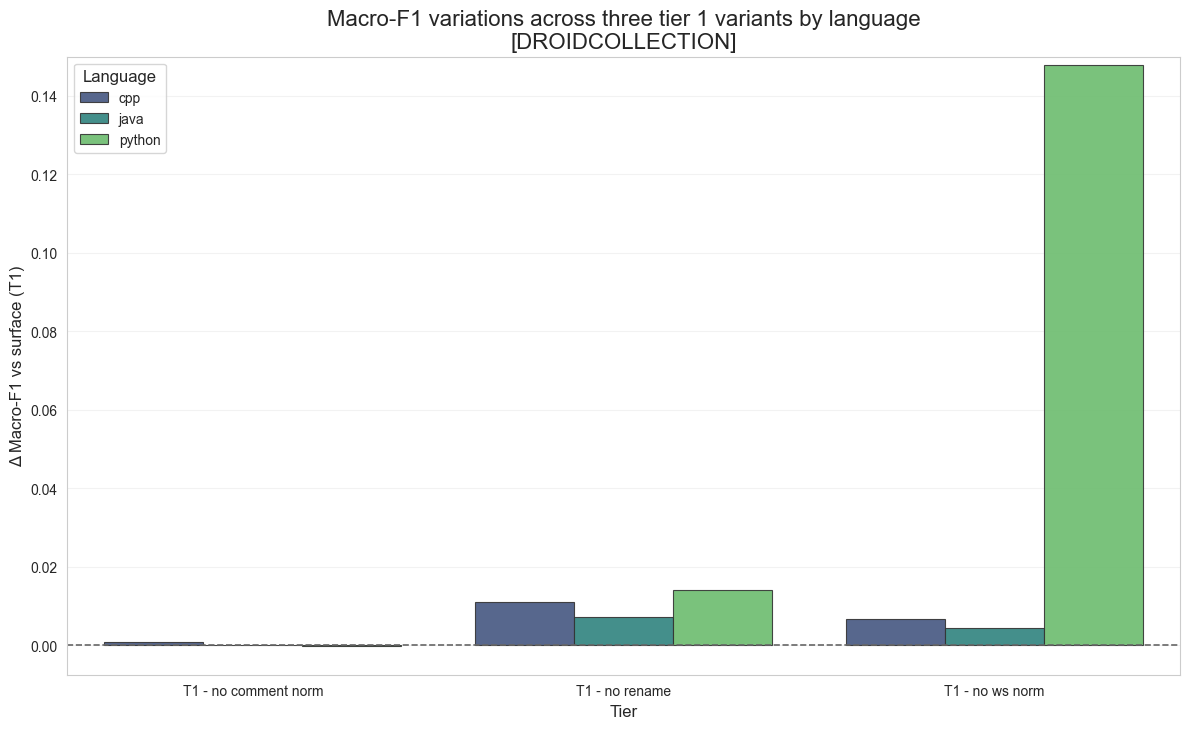

In [53]:
all_lang_deltas = []

for lang in LANGUAGES:
    lang_df = df_raw_abl[df_raw_abl["language"] == lang]
    lang_summary = build_metrics_summary(lang_df, models=ALL_MODELS, tiers=abl_tiers)
    lang_delta = build_delta_summary(lang_summary, baseline=TIER_NAME)
    
    all_lang_deltas.append(lang_delta)

combined_delta_df = pd.concat(all_lang_deltas, ignore_index=True)

plot_ablation_barplot_by_language(combined_delta_df, tiers=ABLATION_TIERS, baseline=TIER_NAME)

## CodeBLEU

In [54]:
cb_scores = pd.read_csv("output/code_bleu_scores.csv")
cb_scores.head()

,Unnamed: 0,dataset,tier,snippet_id,language,codebleu,ngram_match_score,weighted_ngram_match_score,syntax_match_score,dataflow_match_score
0,0,droidcollection,tier_1,row_0,cpp,0.563493,0.414269,0.429418,0.425439,0.984848
1,1,droidcollection,tier_1,row_1,cpp,0.720477,0.660267,0.676188,0.545455,1.000000
2,2,droidcollection,tier_1,row_2,java,0.419661,0.305730,0.334231,0.189944,0.848739
3,3,droidcollection,tier_1,row_3,cpp,0.460496,0.424137,0.433568,0.150943,0.833333
4,4,droidcollection,tier_1,row_4,cpp,0.341427,0.139502,0.175602,0.212766,0.837838


In [55]:
print(df_raw.columns)

Index(['model_name', 'model_type', 'tier', 'snippet_id', 'true_label',
       'pred_label', 'is_correct', 'conf_target', 'entropy', 'mutual_info',
       'language'],
      dtype='object')


In [56]:
components = ["codebleu", "weighted_ngram_match_score", "syntax_match_score", "dataflow_match_score"]

cb_current_ds = cb_scores[cb_scores["dataset"] == DATASET_NAME]
merged_df = pd.merge(
    df_raw,
    cb_current_ds[['snippet_id', 'tier', 'language'] + components],
    on=['snippet_id', 'tier', 'language'],
    how='inner'
)

merged_df.head()

,model_name,model_type,tier,snippet_id,true_label,pred_label,is_correct,conf_target,entropy,mutual_info,language,codebleu,weighted_ngram_match_score,syntax_match_score,dataflow_match_score
0,codebert,encoder,tier_1,row_0,1,1,1,0.999830,0.001642,0.000002,cpp,0.563493,0.429418,0.425439,0.984848
1,codebert,encoder,tier_1,row_1,0,0,1,0.999627,0.003313,0.000008,cpp,0.720477,0.676188,0.545455,1.000000
2,codebert,encoder,tier_1,row_2,0,0,1,0.999506,0.004255,0.000007,java,0.419661,0.334231,0.189944,0.848739
3,codebert,encoder,tier_1,row_3,0,0,1,0.999228,0.006304,0.000023,cpp,0.460496,0.433568,0.150943,0.833333
4,codebert,encoder,tier_1,row_4,0,0,1,0.991596,0.048531,0.000822,cpp,0.341427,0.175602,0.212766,0.837838


Saved: output\figures\droidcollection_corr_cb_entropy_by_lang.pdf


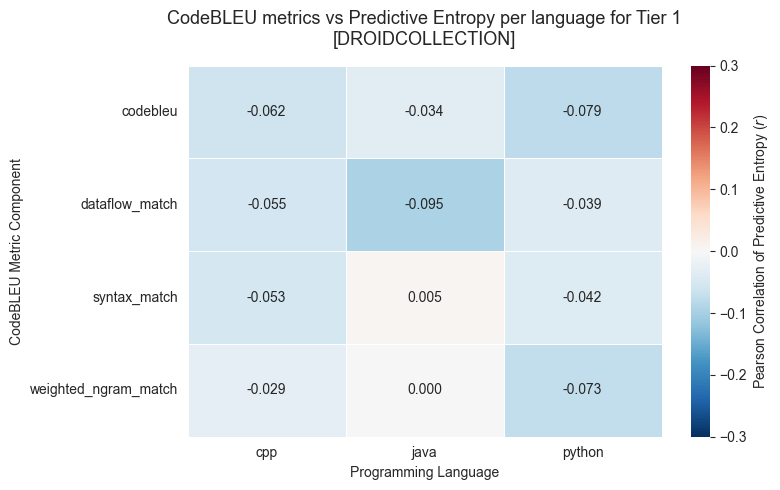

Saved: output\figures\droidcollection_corr_cb_mutual_info_by_lang.pdf


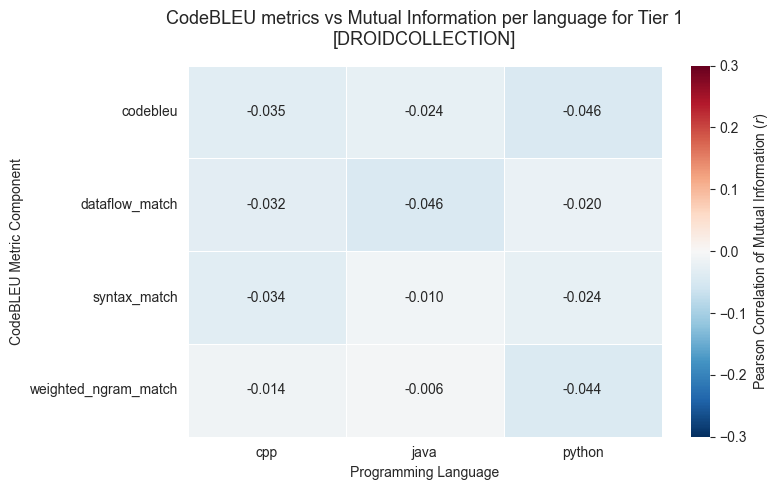

In [57]:
def plot_component_correlation(df_source, metrics, tier="tier_1", languages=LANGUAGES):
    df_source = df_source.copy()

    for metric in metrics:
        corr_list = []

        for lang in languages:
            lang_subset = df_source[(df_source['language'] == lang) & (df_source['tier'] == tier)]
            
            for col in components:
                r = lang_subset[col].corr(lang_subset[metric], method='pearson')
                corr_list.append({'Language': lang, 'Component': col.replace('_score', ''), 'Correlation': r})

        corr_df = pd.DataFrame(corr_list)
        heatmap_data = corr_df.pivot(index='Component', columns='Language', values='Correlation')
        fig, ax = plt.subplots(figsize=(8, 5))

        sns.heatmap(
            heatmap_data, 
            annot=True,
            cmap="RdBu_r",
            vmin=-0.3,
            vmax=0.3,
            fmt=".3f",
            linewidths=.5,
            cbar_kws={"label": f"Pearson Correlation of {METRIC_LABELS[metric]} ($r$)"},
            ax=ax
        )

        ds_name = DATASET_NAME.upper().replace("_", "-")
        ax.set_title(f'CodeBLEU metrics vs {METRIC_LABELS[metric]} per language for {tier.replace("_", " ").title()}\n[{ds_name}]', fontsize=13, pad=15)
        ax.set_ylabel('CodeBLEU Metric Component')
        ax.set_xlabel('Programming Language')

        save_path = f"{DATASET_NAME}_corr_cb_{metric}_by_lang"
        save_figure(fig, save_path)

        plt.tight_layout()
        plt.show()

plot_component_correlation(merged_df, metrics=["entropy", "mutual_info"])